# Training Regressor Algorithm for Predict Hb

### Z-Score Normalization - Concenate Dataset Primer & Sekunder

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. DATA LOADING
# ==========================================
print("Memuat dataset...")
# Sesuaikan path ini dengan lokasi file Excel Anda
PATH_PRIMER = r"C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\hasil_ekstraksi_fitur_primer2.xlsx"
PATH_SEKUNDER = r"C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\hasil_ekstraksi_fitur_Eyedefy2.xlsx"
OUTPUT_GABUNGAN = r"C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\dataset_gabungan_normalized.xlsx"

# Membaca file Excel
df_primer = pd.read_excel(PATH_PRIMER) 
df_sekunder = pd.read_excel(PATH_SEKUNDER)

print(f"Data Primer dimuat   : {df_primer.shape[0]} baris")
print(f"Data Sekunder dimuat : {df_sekunder.shape[0]} baris")


# ==========================================
# 2. IDENTIFIKASI KOLOM (FITUR vs TARGET vs METADATA)
# ==========================================
# Gabungkan semua nama kolom non-fitur dari kedua dataset agar tidak ikut ter-scaling
kolom_metadata_dan_target = [
    'Subjek', 'Device', 'Posisi_Mata',            # Khusus Primer
    'Country', 'Subject_ID', 'Age', 'Anemia_Class', # Khusus Sekunder
    'Gender', 'Hemoglobin'                        # Ada di Keduanya (Target Prediksi)
]

# Mengambil nama-nama fitur warna secara dinamis (mengabaikan metadata di atas)
fitur_warna = [col for col in df_primer.columns if col not in kolom_metadata_dan_target]

print(f"\nJumlah fitur warna yang akan dinormalisasi: {len(fitur_warna)} fitur")


# ==========================================
# 3. INDEPENDENT NORMALIZATION (Z-SCORE)
# ==========================================
print("Melakukan Independent Normalization (Z-Score)...")

scaler_primer = StandardScaler()
scaler_sekunder = StandardScaler()

# Buat salinan agar data asli tidak tertimpa
df_primer_scaled = df_primer.copy()
df_sekunder_scaled = df_sekunder.copy()

# Fit & Transform HANYA pada 30 kolom fitur warna
df_primer_scaled[fitur_warna] = scaler_primer.fit_transform(df_primer[fitur_warna])
df_sekunder_scaled[fitur_warna] = scaler_sekunder.fit_transform(df_sekunder[fitur_warna])


# ==========================================
# 4. PENGGABUNGAN DATA (CONCATENATION)
# ==========================================
# Menambahkan penanda dataset sebelum digabung
df_primer_scaled['Sumber_Dataset'] = 'Primer'
df_sekunder_scaled['Sumber_Dataset'] = 'Sekunder'

# Menggabungkan kedua dataframe
# (Metadata yang tidak ada di salah satu tabel akan otomatis diisi NaN, dan itu sangat aman)
df_gabungan = pd.concat([df_primer_scaled, df_sekunder_scaled], ignore_index=True)

print(f"Data berhasil digabungkan! Total: {df_gabungan.shape[0]} baris, {df_gabungan.shape[1]} kolom")


# ==========================================
# 5. MENYIMPAN KE EXCEL
# ==========================================
print("\nMenyimpan dataset gabungan ke Excel...")
df_gabungan.to_excel(OUTPUT_GABUNGAN, index=False)
print(f"Selesai! File berhasil disimpan di:\n{OUTPUT_GABUNGAN}")

Memuat dataset...
Data Primer dimuat   : 77 baris
Data Sekunder dimuat : 211 baris

Jumlah fitur warna yang akan dinormalisasi: 30 fitur
Melakukan Independent Normalization (Z-Score)...
Data berhasil digabungkan! Total: 288 baris, 40 kolom

Menyimpan dataset gabungan ke Excel...
Selesai! File berhasil disimpan di:
C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\dataset_gabungan_normalized.xlsx


### Train (Zero Shot)
#### Training pake dataset sekunder -> di test pake dataset primer

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
print("Memuat dataset gabungan...")
PATH_GABUNGAN = r"C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\dataset_gabungan_normalized.xlsx"
df = pd.read_excel(PATH_GABUNGAN)

# Encode Gender (Laki-laki/M = 1, Perempuan/F = 0)
# Gender sangat penting dimasukkan sebagai fitur karena kadar normal Hb pria dan wanita berbeda
def encode_gender(g):
    g_str = str(g).strip().upper()
    if g_str in ['M', 'MALE', 'LAKI-LAKI', 'L']:
        return 1
    elif g_str in ['F', 'FEMALE', 'PEREMPUAN', 'P', 'W']:
        return 0
    return 0 # Default jika Unknown

df['Gender_Encoded'] = df['Gender'].apply(encode_gender)

# Tentukan Kolom Fitur (X) dan Target (y)
# Kita membuang semua metadata teks dan target dari fitur X
kolom_non_fitur = ['Subjek', 'Device', 'Posisi_Mata', 'Country', 'Subject_ID', 
                   'Age', 'Anemia_Class', 'Gender', 'Hemoglobin', 'Sumber_Dataset']

X_columns = [col for col in df.columns if col not in kolom_non_fitur]
# Tambahkan Gender_Encoded ke dalam fitur
X_columns.append('Gender_Encoded')

Memuat dataset gabungan...


## Split Data Train (Sekunder) -> Test (Primer)

In [4]:
# ==========================================
# 2. DATA SPLITTING (CROSS-DOMAIN SCENARIO)
# ==========================================
# TRAIN: 100% Data Sekunder (Eyedefy)
# TEST: 100% Data Primer (Smartphone)

train_data = df[df['Sumber_Dataset'] == 'Sekunder'].copy()
test_data = df[df['Sumber_Dataset'] == 'Primer'].copy()

# Hapus baris yang mungkin memiliki nilai Hemoglobin kosong (NaN)
train_data = train_data.dropna(subset=['Hemoglobin'])
test_data = test_data.dropna(subset=['Hemoglobin'])

X_train = train_data[X_columns]
y_train = train_data['Hemoglobin']

X_test = test_data[X_columns]
y_test = test_data['Hemoglobin']

print(f"\nDistribusi Data Latih (Sekunder) : {X_train.shape[0]} sampel")
print(f"Distribusi Data Uji (Primer)     : {X_test.shape[0]} sampel")


Distribusi Data Latih (Sekunder) : 211 sampel
Distribusi Data Uji (Primer)     : 77 sampel


In [5]:
models = {
    'Multiple Linear Regression (MLR)': LinearRegression(),
    'Support Vector Regression (SVR)': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Random Forest (RF)': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting (GB)': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

print("\nMelatih Model dan Menghitung Evaluasi...")
print("-" * 50)

for name, model in models.items():
    # 1. Melatih model
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # 2. Prediksi pada data uji (Primer)
    y_pred = model.predict(X_test)
    
    # 3. Hitung Metrik Evaluasi
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # 4. Simpan hasil
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R-Squared': r2})
    
    print(f"{name}:")
    print(f"  RMSE : {rmse:.4f} g/dL")
    print(f"  MAE  : {mae:.4f} g/dL")
    print(f"  R2   : {r2:.4f}\n")

df_results = pd.DataFrame(results).sort_values(by='RMSE')
display(df_results)


Melatih Model dan Menghitung Evaluasi...
--------------------------------------------------
Multiple Linear Regression (MLR):
  RMSE : 12.1191 g/dL
  MAE  : 9.7364 g/dL
  R2   : -28.1375

Support Vector Regression (SVR):
  RMSE : 2.0952 g/dL
  MAE  : 1.5586 g/dL
  R2   : 0.1291

Random Forest (RF):
  RMSE : 2.1725 g/dL
  MAE  : 1.6813 g/dL
  R2   : 0.0636

Gradient Boosting (GB):
  RMSE : 2.1410 g/dL
  MAE  : 1.6571 g/dL
  R2   : 0.0906



,Model,RMSE,MAE,R-Squared
1,Support Vector Regression (SVR),2.095191,1.558608,0.129112
3,Gradient Boosting (GB),2.140972,1.657075,0.090638
2,Random Forest (RF),2.172534,1.681305,0.063629
0,Multiple Linear Regression (MLR),12.119060,9.736401,-28.137527


### Fine Tuning - Split Data Primer & Sekunder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
print("Memuat dataset gabungan...")
PATH_GABUNGAN = r"C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\dataset_gabungan_normalized.xlsx"
df = pd.read_excel(PATH_GABUNGAN)

# Encode Gender (Laki-laki/M = 1, Perempuan/F = 0)
def encode_gender(g):
    g_str = str(g).strip().upper()
    if g_str in ['M', 'MALE', 'LAKI-LAKI', 'L']:
        return 1
    elif g_str in ['F', 'FEMALE', 'PEREMPUAN', 'P', 'W']:
        return 0
    return 0 

df['Gender_Encoded'] = df['Gender'].apply(encode_gender)

# Tentukan Kolom Fitur (X) dan Target (y)
kolom_non_fitur = ['Subjek', 'Device', 'Posisi_Mata', 'Country', 'Subject_ID', 
                   'Age', 'Anemia_Class', 'Gender', 'Hemoglobin', 'Sumber_Dataset']

X_columns = [col for col in df.columns if col not in kolom_non_fitur]

# Hapus baris yang mungkin memiliki nilai Hemoglobin kosong (NaN)
df = df.dropna(subset=['Hemoglobin'])

Memuat dataset gabungan...


## Split Data
#### Training (80% Primer + 100% Sekunder)
#### Test (20 % Primer)

In [3]:
# ==========================================
# 2. DATA SPLITTING (FINE-TUNING SCENARIO)
# ==========================================
print("\nMelakukan pemisahan dan pencampuran data (Data Mixing)...")

# Pisahkan dataset berdasarkan sumbernya
df_sekunder = df[df['Sumber_Dataset'] == 'Sekunder'].copy()
df_primer = df[df['Sumber_Dataset'] == 'Primer'].copy()

# Pecah data Primer menjadi 80% Train dan 20% Test
# Gunakan random_state agar pembagiannya konsisten setiap kali code dijalankan
primer_train, primer_test = train_test_split(df_primer, test_size=0.2, random_state=42)

# BENTUK TRAINING SET: 100% Sekunder + 80% Primer
train_data = pd.concat([df_sekunder, primer_train], ignore_index=True)

# BENTUK TESTING SET: 20% Sisa Primer
test_data = primer_test.copy()

X_train = train_data[X_columns]
y_train = train_data['Hemoglobin']

X_test = test_data[X_columns]
y_test = test_data['Hemoglobin']

print(f"Data Latih (Train) : {df_sekunder.shape[0]} Sekunder + {primer_train.shape[0]} Primer = {X_train.shape[0]} sampel")
print(f"Data Uji (Test)    : Murni {X_test.shape[0]} Primer")


Melakukan pemisahan dan pencampuran data (Data Mixing)...
Data Latih (Train) : 211 Sekunder + 61 Primer = 272 sampel
Data Uji (Test)    : Murni 16 Primer


### Feature Selection

### MI

Melakukan Feature Selection menggunakan Mutual Information (MI)...

10 Fitur Terpilih (Mutual Information):
 1. A_Mean
 2. Gender_Encoded
 3. Red_Ratio
 4. High_Hue_Ratio
 5. B_lab_Mean
 6. B_lab_Std
 7. S_Mean
 8. B_Mean
 9. A_Std
 10. Erythema_Index


C:\Users\dzakw\AppData\Local\Temp\ipykernel_9184\2160289692.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.head(10).values, y=mi_series.head(10).index, palette='viridis')


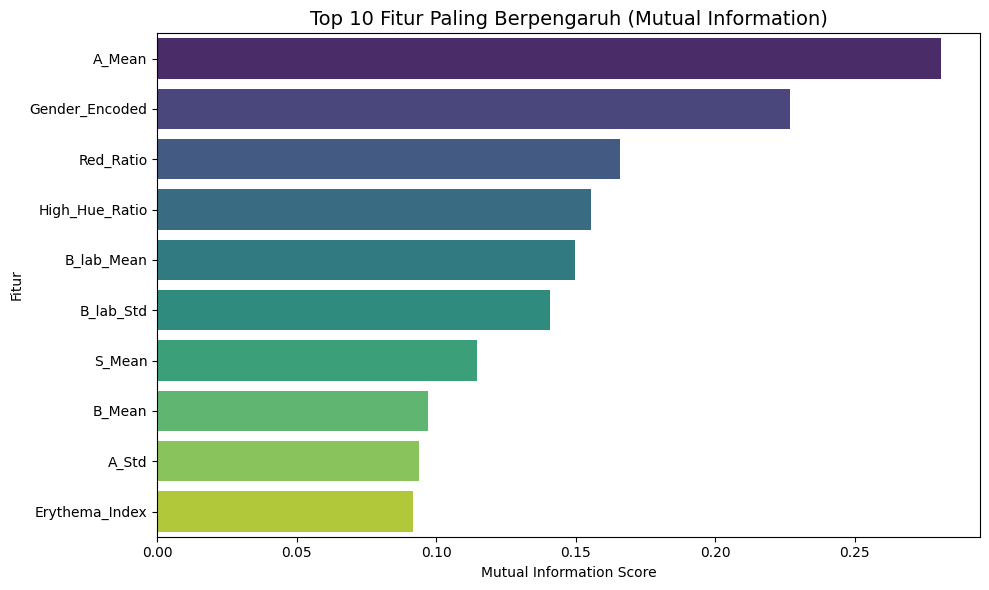

In [4]:
from sklearn.feature_selection import mutual_info_regression
# ==========================================
# 2A. FEATURE SELECTION: MUTUAL INFORMATION (MI)
# ==========================================
print("Melakukan Feature Selection menggunakan Mutual Information (MI)...")

# Menghitung skor MI (menggunakan random_state di numpy untuk konsistensi)
np.random.seed(42) 
mi_scores = mutual_info_regression(X_train, y_train)

# Mengubah hasil menjadi Pandas Series dan mengurutkannya dari yang terbesar
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)
top_10_mi_features = mi_series.head(10).index.tolist()

print("\n10 Fitur Terpilih (Mutual Information):")
for i, f in enumerate(top_10_mi_features):
    print(f" {i+1}. {f}")

# Visualisasi Hasil MI
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.head(10).values, y=mi_series.head(10).index, palette='viridis')
plt.title('Top 10 Fitur Paling Berpengaruh (Mutual Information)', fontsize=14)
plt.xlabel('Mutual Information Score')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

### PCC


10 Fitur Terpilih (Berdasarkan Nilai Absolut Pearson Correlation):
 1. Gender_Encoded (PCC Asli: 0.589 | Absolut: 0.589)
 2. B_lab_Std (PCC Asli: 0.525 | Absolut: 0.525)
 3. A_Mean (PCC Asli: 0.524 | Absolut: 0.524)
 4. Red_Ratio (PCC Asli: 0.507 | Absolut: 0.507)
 5. B_lab_Mean (PCC Asli: 0.468 | Absolut: 0.468)
 6. Erythema_Index (PCC Asli: 0.461 | Absolut: 0.461)
 7. S_Mean (PCC Asli: 0.458 | Absolut: 0.458)
 8. High_Hue_Ratio (PCC Asli: 0.442 | Absolut: 0.442)
 9. S_Std (PCC Asli: 0.349 | Absolut: 0.349)
 10. B_Mean (PCC Asli: -0.338 | Absolut: 0.338)


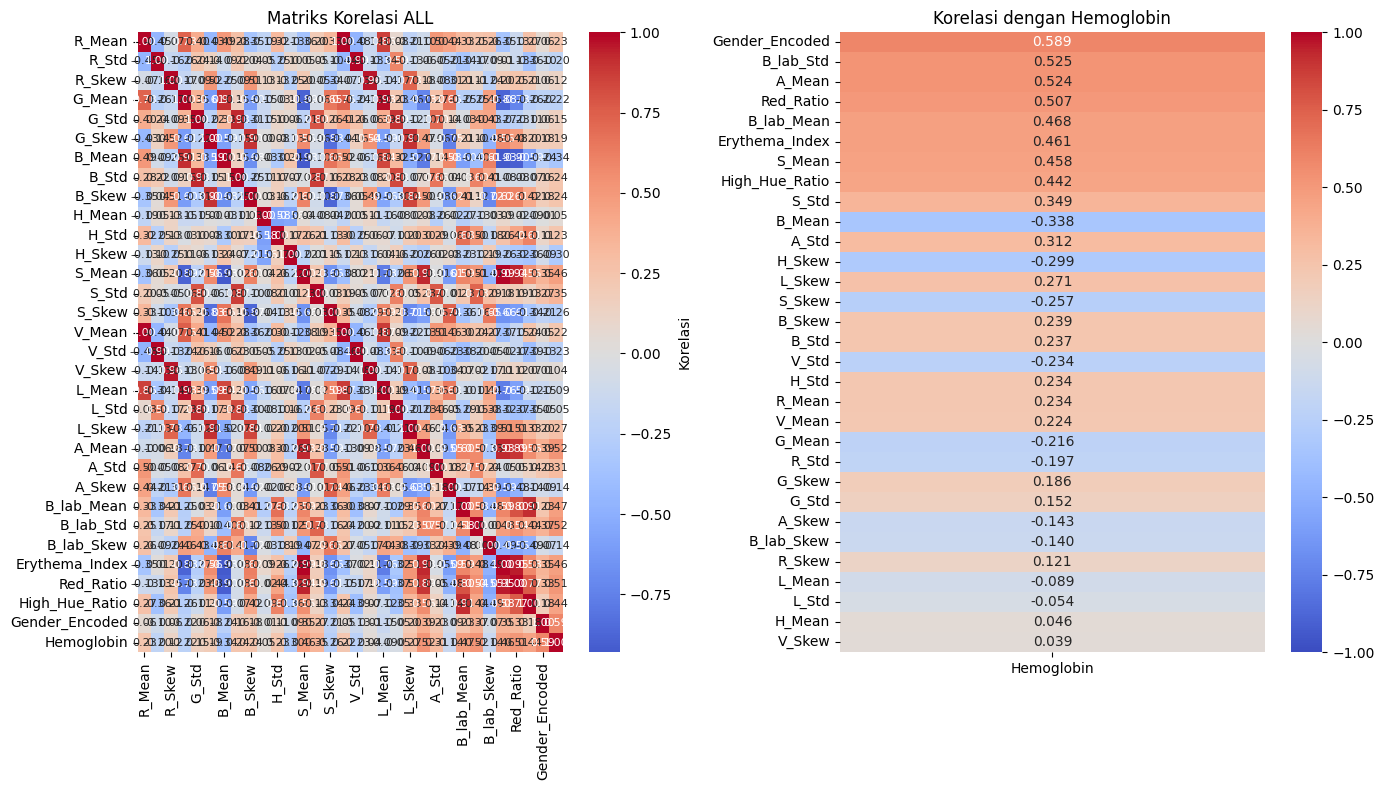

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan X_train dan y_train sudah terdefinisi

train_corr_df = X_train.copy()
train_corr_df['Hemoglobin'] = y_train

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# ---------------------------------------------------------
# 1. Heatmap: Matriks Korelasi Keseluruhan
# ---------------------------------------------------------
correlation_matrix = train_corr_df.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Korelasi'}, annot_kws={'fontsize': 8}, ax=axes[0])
axes[0].set_title('Matriks Korelasi ALL')

# ---------------------------------------------------------
# 2. Heatmap: Korelasi dengan Hemoglobin (Diurutkan secara Absolut)
# ---------------------------------------------------------
# Ekstrak korelasi terhadap Hemoglobin dan buang baris target itu sendiri
correlation_with_hb = correlation_matrix[['Hemoglobin']].drop('Hemoglobin')

# Buat kolom bantuan berisi nilai absolut untuk acuan pengurutan
correlation_with_hb['Abs_Korelasi'] = correlation_with_hb['Hemoglobin'].abs()

# Urutkan berdasarkan nilai absolut secara descending (dari yang terkuat ke terlemah)
correlation_sorted = correlation_with_hb.sort_values(by='Abs_Korelasi', ascending=False)

# Siapkan data untuk plot (hanya memunculkan nilai aslinya, bukan absolutnya)
correlation_1d_plot = correlation_sorted[['Hemoglobin']]

sns.heatmap(correlation_1d_plot, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt='.3f', ax=axes[1])
axes[1].set_title('Korelasi dengan Hemoglobin')

# ---------------------------------------------------------
# 3. Ekstraksi Top 10 Fitur
# ---------------------------------------------------------
# Ambil top 10 fitur dari dataframe yang sudah diurutkan berdasarkan nilai absolut
top_10_pcc_features = correlation_sorted.head(10).index.tolist()

print("\n10 Fitur Terpilih (Berdasarkan Nilai Absolut Pearson Correlation):")
for i, f in enumerate(top_10_pcc_features):
    nilai_asli = correlation_sorted.loc[f, 'Hemoglobin']
    nilai_abs = correlation_sorted.loc[f, 'Abs_Korelasi']
    print(f" {i+1}. {f} (PCC Asli: {nilai_asli:.3f} | Absolut: {nilai_abs:.3f})")

plt.tight_layout()
plt.show()

### RF

Melakukan Feature Selection menggunakan Random Forest (RF)...

10 Fitur Terpilih (Random Forest):
 1. Gender_Encoded
 2. A_Mean
 3. B_lab_Mean
 4. High_Hue_Ratio
 5. B_lab_Std
 6. Red_Ratio
 7. R_Mean
 8. H_Skew
 9. V_Mean
 10. B_lab_Skew


C:\Users\dzakw\AppData\Local\Temp\ipykernel_9184\3617840981.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=top_10_rf_features, palette='mako')


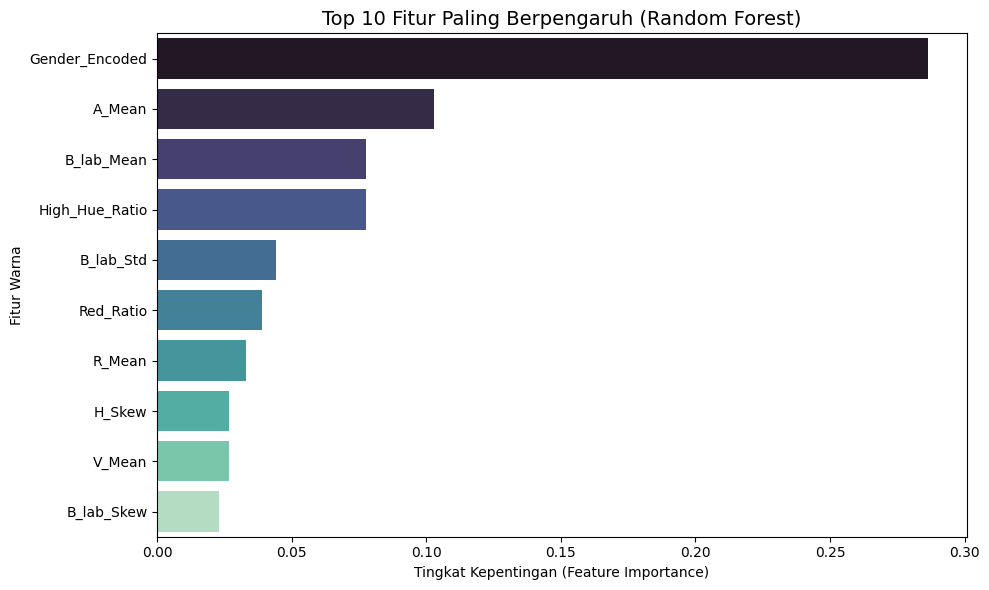

In [6]:
# ==========================================
# 2. FEATURE SELECTION: RANDOM FOREST (RF)
# ==========================================
print("Melakukan Feature Selection menggunakan Random Forest (RF)...")

# Inisialisasi dan latih model Random Forest
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

# Ekstrak Feature Importances dari model yang sudah dilatih
importances = rf_selector.feature_importances_

# Urutkan indeks dari nilai yang paling besar (descending) dan ambil 10 teratas
indices = np.argsort(importances)[::-1][:10]

# Buat list yang berisi nama 10 fitur terbaik
top_10_rf_features = [X_columns[i] for i in indices]

print("\n10 Fitur Terpilih (Random Forest):")
for i, f in enumerate(top_10_rf_features):
    print(f" {i+1}. {f}")

# Visualisasi Hasil Feature Importance Random Forest
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=top_10_rf_features, palette='mako')
plt.title('Top 10 Fitur Paling Berpengaruh (Random Forest)', fontsize=14)
plt.xlabel('Tingkat Kepentingan (Feature Importance)')
plt.ylabel('Fitur Warna')
plt.tight_layout()
plt.show()

### Irisan Fitur

In [7]:
# ==========================================
# 2D. ENSEMBLE FEATURE SELECTION (IRISAN / INTERSECTION)
# ==========================================
print("Mencari irisan (intersection) fitur dari Random Forest, MI, dan PCC...")

# Mengubah ketiga list menjadi himpunan (set) dan mencari irisannya dengan operator '&'
irisan_fitur = list(set(top_10_rf_features) & set(top_10_mi_features) & set(top_10_pcc_features))

print(f"\nDitemukan {len(irisan_fitur)} fitur yang disetujui oleh KETIGA metode:")
for i, f in enumerate(irisan_fitur):
    print(f" {i+1}. {f}")

# Tindakan pencegahan jika irisan ternyata terlalu sedikit (misal: kurang dari 3)
if len(irisan_fitur) < 3:
    print("\n⚠️ Peringatan: Irisan fitur terlalu sedikit.")
    print("Mencoba opsi alternatif: Mengambil fitur yang disetujui oleh MINIMAL DUA metode (Majority Vote)...")
    
    # Menggabungkan semua fitur
    semua_fitur = top_10_rf_features + top_10_mi_features + top_10_pcc_features
    
    # Menghitung frekuensi kemunculan setiap fitur
    frekuensi_fitur = pd.Series(semua_fitur).value_counts()
    
    # Mengambil fitur yang muncul minimal 2 kali
    irisan_fitur = frekuensi_fitur[frekuensi_fitur >= 2].index.tolist()
    
    print(f"\nDitemukan {len(irisan_fitur)} fitur dari hasil Majority Vote:")
    for i, f in enumerate(irisan_fitur):
        print(f" {i+1}. {f} (Muncul di {frekuensi_fitur[f]} metode)")

# Memotong dataset latih dan uji agar hanya memiliki fitur hasil ensemble
X_train_selected = X_train[irisan_fitur]
X_test_selected = X_test[irisan_fitur]

print(f"\nDataset siap diproses ke tahap Hyperparameter Tuning dengan {X_train_selected.shape[1]} fitur.")

Mencari irisan (intersection) fitur dari Random Forest, MI, dan PCC...

Ditemukan 6 fitur yang disetujui oleh KETIGA metode:
 1. B_lab_Std
 2. Gender_Encoded
 3. A_Mean
 4. High_Hue_Ratio
 5. B_lab_Mean
 6. Red_Ratio

Dataset siap diproses ke tahap Hyperparameter Tuning dengan 6 fitur.


### Gabungan Fitur

In [7]:
# ==========================================
# 2D. ENSEMBLE FEATURE SELECTION (GABUNGAN / UNION)
# ==========================================
print("Mencari gabungan (union) fitur dari Random Forest, MI, dan PCC...")

# Mengubah ketiga list menjadi himpunan (set) dan mencari gabungannya dengan operator '|'
gabungan_fitur = list(set(top_10_rf_features) | set(top_10_mi_features) | set(top_10_pcc_features))

print(f"\nDitemukan total {len(gabungan_fitur)} fitur unik dari gabungan KETIGA metode:")
for i, f in enumerate(gabungan_fitur):
    print(f" {i+1}. {f}")

# Memotong dataset latih dan uji agar hanya memiliki fitur hasil gabungan
X_train_selected = X_train[gabungan_fitur]
X_test_selected = X_test[gabungan_fitur]

print(f"\nDataset siap diproses ke tahap Hyperparameter Tuning dengan {X_train_selected.shape[1]} fitur.")

Mencari gabungan (union) fitur dari Random Forest, MI, dan PCC...

Ditemukan total 15 fitur unik dari gabungan KETIGA metode:
 1. B_lab_Skew
 2. A_Std
 3. Erythema_Index
 4. S_Mean
 5. R_Mean
 6. Gender_Encoded
 7. A_Mean
 8. B_lab_Mean
 9. S_Std
 10. High_Hue_Ratio
 11. H_Skew
 12. V_Mean
 13. B_Mean
 14. Red_Ratio
 15. B_lab_Std

Dataset siap diproses ke tahap Hyperparameter Tuning dengan 15 fitur.


## Model Initialization 
### (Train w/ Default Params + Full Features)

In [8]:
models = {
    'Multiple Linear Regression (MLR)': LinearRegression(),
    'Support Vector Regression (SVR)': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Random Forest (RF)': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting (GB)': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

print("\nMelatih Model dan Menghitung Evaluasi...")
print("-" * 50)

for name, model in models.items():
    # 1. Melatih model
    model.fit(X_train, y_train) #full fitur
    trained_models[name] = model
    
    # 2. Prediksi pada data uji (20% Primer)
    y_pred = model.predict(X_test)
    
    # 3. Hitung Metrik Evaluasi
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R-Squared': r2})
    
    print(f"{name}:")
    print(f"  RMSE : {rmse:.4f} g/dL")
    print(f"  MAE  : {mae:.4f} g/dL")
    print(f"  R2   : {r2:.4f}\n")

df_results = pd.DataFrame(results).sort_values(by='RMSE')
display(df_results)


Melatih Model dan Menghitung Evaluasi...
--------------------------------------------------
Multiple Linear Regression (MLR):
  RMSE : 2.3208 g/dL
  MAE  : 1.7951 g/dL
  R2   : 0.0040

Support Vector Regression (SVR):
  RMSE : 2.0674 g/dL
  MAE  : 1.5034 g/dL
  R2   : 0.2095

Random Forest (RF):
  RMSE : 1.7844 g/dL
  MAE  : 1.3012 g/dL
  R2   : 0.4111

Gradient Boosting (GB):
  RMSE : 1.9796 g/dL
  MAE  : 1.3501 g/dL
  R2   : 0.2752



,Model,RMSE,MAE,R-Squared
2,Random Forest (RF),1.784440,1.301175,0.411130
3,Gradient Boosting (GB),1.979645,1.350082,0.275246
1,Support Vector Regression (SVR),2.067442,1.503385,0.209535
0,Multiple Linear Regression (MLR),2.320753,1.795135,0.003967


### Train using Best Features

In [9]:
results = []
trained_models = {}

print("\nMelatih Model dan Menghitung Evaluasi...")
print("-" * 50)

for name, model in models.items():
    # 1. Melatih model
    model.fit(X_train_selected, y_train) #full fitur
    trained_models[name] = model
    
    # 2. Prediksi pada data uji (20% Primer)
    y_pred = model.predict(X_test_selected)
    
    # 3. Hitung Metrik Evaluasi
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R-Squared': r2})
    
    print(f"{name}:")
    print(f"  RMSE : {rmse:.4f} g/dL")
    print(f"  MAE  : {mae:.4f} g/dL")
    print(f"  R2   : {r2:.4f}\n")

df_results = pd.DataFrame(results).sort_values(by='RMSE')
display(df_results)


Melatih Model dan Menghitung Evaluasi...
--------------------------------------------------
Multiple Linear Regression (MLR):
  RMSE : 1.8370 g/dL
  MAE  : 1.3059 g/dL
  R2   : 0.3760

Support Vector Regression (SVR):
  RMSE : 1.9110 g/dL
  MAE  : 1.5025 g/dL
  R2   : 0.3246

Random Forest (RF):
  RMSE : 1.7541 g/dL
  MAE  : 1.4335 g/dL
  R2   : 0.4310

Gradient Boosting (GB):
  RMSE : 1.9752 g/dL
  MAE  : 1.5605 g/dL
  R2   : 0.2785



,Model,RMSE,MAE,R-Squared
2,Random Forest (RF),1.754128,1.433531,0.430965
0,Multiple Linear Regression (MLR),1.836952,1.305904,0.375961
1,Support Vector Regression (SVR),1.911005,1.502493,0.324633
3,Gradient Boosting (GB),1.975249,1.560505,0.278461


### Hyperparameter Tuning Algorithms

Pakai semua fitur

In [34]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Memulai Hyperparameter Tuning dengan GridSearchCV...")
print("Proses ini akan memakan waktu beberapa menit, mohon tunggu...\n")

# 1. Definisikan ruang pencarian (Parameter Grid) untuk model terbaik
param_grids = {
    'Support Vector Regression (SVR)': {
        'C': [0.1, 1.0, 10.0, 100.0],
        'gamma': ['scale', 'auto', 0.1, 0.01],
        'epsilon': [0.01, 0.1, 0.5]
    },
    'Random Forest (RF)': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting (GB)': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
}

# Ambil model dari dictionary models yang sudah Anda buat sebelumnya
# (Kita tidak men-tuning MLR karena MLR standar tidak memiliki banyak parameter)
models_to_tune = {
    'Support Vector Regression (SVR)': models['Support Vector Regression (SVR)'],
    'Random Forest (RF)': models['Random Forest (RF)'],
    'Gradient Boosting (GB)': models['Gradient Boosting (GB)']
}

tuned_results = []
best_models = {}

for name, base_model in models_to_tune.items():
    print(f"Mencari parameter terbaik untuk {name}...")
    
    # Inisialisasi GridSearchCV
    # cv=5 berarti melakukan 5-Fold Cross Validation saat mencari parameter
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[name],
        scoring='r2', 
        cv=5, 
        n_jobs=-1, # Menggunakan seluruh core CPU agar proses lebih cepat
        verbose=1  # Menampilkan progres
    )
    
    # Eksekusi pencarian pada data latih (Campuran)
    grid_search.fit(X_train, y_train)
    
    # Simpan model terbaik
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    # Uji model terbaik pada data uji murni (20% Primer)
    y_pred = best_model.predict(X_test)
    
    # Hitung metrik final
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    tuned_results.append({
        'Model': name, 
        'RMSE': rmse, 
        'MAE': mae, 
        'R-Squared': r2,
        'Best Params': str(grid_search.best_params_)
    })

print("\n" + "="*50)
print("HASIL EVALUASI SETELAH HYPERPARAMETER TUNING")
print("="*50)

# Tampilkan hasil secara berurutan dari R-Squared terbesar
df_tuned_results = pd.DataFrame(tuned_results).sort_values(by='R-Squared', ascending=False)
# Hapus batas maksimal lebar kolom
pd.set_option('display.max_colwidth', None)

# Tampilkan kembali hasilnya
display(df_tuned_results[['Model', 'RMSE', 'MAE', 'R-Squared', 'Best Params']])

Memulai Hyperparameter Tuning dengan GridSearchCV...
Proses ini akan memakan waktu beberapa menit, mohon tunggu...

Mencari parameter terbaik untuk Support Vector Regression (SVR)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mencari parameter terbaik untuk Random Forest (RF)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mencari parameter terbaik untuk Gradient Boosting (GB)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

HASIL EVALUASI SETELAH HYPERPARAMETER TUNING


,Model,RMSE,MAE,R-Squared,Best Params
1,Random Forest (RF),1.747964,1.263041,0.434958,"{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}"
2,Gradient Boosting (GB),1.944825,1.327879,0.300517,"{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}"
0,Support Vector Regression (SVR),2.225684,1.663145,0.083899,"{'C': 1.0, 'epsilon': 0.5, 'gamma': 0.01}"


##### Best Features Only

In [11]:
from sklearn.model_selection import GridSearchCV
# 1. Definisikan ruang pencarian (Parameter Grid) untuk model terbaik
param_grids = {
    'Support Vector Regression (SVR)': {
        'C': [0.1, 1.0, 10.0, 100.0],
        'gamma': ['scale', 'auto', 0.1, 0.01],
        'epsilon': [0.01, 0.1, 0.5]
    },
    'Random Forest (RF)': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting (GB)': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
}

# Ambil model dari dictionary models yang sudah Anda buat sebelumnya
# (Kita tidak men-tuning MLR karena MLR standar tidak memiliki banyak parameter)
models_to_tune = {
    'Support Vector Regression (SVR)': models['Support Vector Regression (SVR)'],
    'Random Forest (RF)': models['Random Forest (RF)'],
    'Gradient Boosting (GB)': models['Gradient Boosting (GB)']
}

tuned_results = []
best_models = {}

for name, base_model in models_to_tune.items():
    print(f"Mencari parameter terbaik untuk {name}...")
    
    # Inisialisasi GridSearchCV
    # cv=5 berarti melakukan 5-Fold Cross Validation saat mencari parameter
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[name],
        scoring='r2', 
        cv=5, 
        n_jobs=-1, # Menggunakan seluruh core CPU agar proses lebih cepat
        verbose=1  # Menampilkan progres
    )
    
    # Eksekusi pencarian pada data latih (Campuran)
    grid_search.fit(X_train_selected, y_train)
    
    # Simpan model terbaik
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    # Uji model terbaik pada data uji murni (20% Primer)
    y_pred = best_model.predict(X_test_selected)
    
    # Hitung metrik final
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    tuned_results.append({
        'Model': name, 
        'RMSE': rmse, 
        'MAE': mae, 
        'R-Squared': r2,
        'Best Params': str(grid_search.best_params_)
    })

print("\n" + "="*50)
print("HASIL EVALUASI SETELAH HYPERPARAMETER TUNING")
print("="*50)

# Tampilkan hasil secara berurutan dari RMSE terkecil
df_tuned_results = pd.DataFrame(tuned_results).sort_values(by='RMSE')
# Hapus batas maksimal lebar kolom
pd.set_option('display.max_colwidth', None)

# Tampilkan kembali hasilnya
display(df_tuned_results[['Model', 'RMSE', 'MAE', 'R-Squared', 'Best Params']])

Mencari parameter terbaik untuk Support Vector Regression (SVR)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mencari parameter terbaik untuk Random Forest (RF)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mencari parameter terbaik untuk Gradient Boosting (GB)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

HASIL EVALUASI SETELAH HYPERPARAMETER TUNING


,Model,RMSE,MAE,R-Squared,Best Params
1,Random Forest (RF),1.720768,1.407370,0.452404,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}"
2,Gradient Boosting (GB),1.874911,1.485119,0.349904,"{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}"
0,Support Vector Regression (SVR),1.901868,1.471733,0.331076,"{'C': 1.0, 'epsilon': 0.01, 'gamma': 0.1}"


### + Model XGBoost
#### Also using Best Features

In [36]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
# Import XGBoost
from xgboost import XGBRegressor

# BUAT DATAFRAME BARU YANG HANYA BERISI 10 FITUR TERSEBUT
X_train_top = X_train_selected
X_test_top = X_test_selected


# ==========================================
# 1. HYPERPARAMETER TUNING (HANYA PADA 10 FITUR)
# ==========================================
print("\nMemulai Hyperparameter Tuning dengan GridSearchCV...")
print("Proses ini akan memakan waktu beberapa menit, mohon tunggu...\n")

param_grids = {
    'Support Vector Regression (SVR)': {
        'C': [0.1, 1.0, 10.0, 100.0],
        'gamma': ['scale', 'auto', 0.1, 0.01],
        'epsilon': [0.01, 0.1, 0.5]
    },
    'Random Forest (RF)': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting (GB)': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    },
    # Menambahkan XGBoost ke dalam Parameter Grid
    'XGBoost (XGB)': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
}

# Inisialisasi ulang model dasar termasuk XGBoost
models_to_tune = {
    'Support Vector Regression (SVR)': SVR(),
    'Random Forest (RF)': RandomForestRegressor(random_state=42),
    'Gradient Boosting (GB)': GradientBoostingRegressor(random_state=42),
    'XGBoost (XGB)': XGBRegressor(random_state=42, objective='reg:squarederror')
}

tuned_results = []
best_models = {}

for name, base_model in models_to_tune.items():
    print(f"Mencari parameter terbaik untuk {name}...")
    
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[name],
        scoring='r2', 
        cv=5, 
        n_jobs=-1, 
        verbose=1  
    )
    
    # -------------------------------------------------------------
    # PERHATIKAN: Kita memanggil X_train_top10, BUKAN X_train
    # -------------------------------------------------------------
    grid_search.fit(X_train_top, y_train)
    
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    # PERHATIKAN: Memprediksi X_test_top10, BUKAN X_test
    y_pred = best_model.predict(X_test_top)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    tuned_results.append({
        'Model': name, 
        'RMSE': rmse, 
        'MAE': mae, 
        'R-Squared': r2,
        'Best Params': str(grid_search.best_params_)
    })

print("\n" + "="*50)
print("HASIL EVALUASI TUNING (TOP 10 FITUR + RANDOM SPLIT)")
print("="*50)

df_tuned_results = pd.DataFrame(tuned_results).sort_values(by='R-Squared', ascending=False)

# Hapus batas maksimal agar Best Params terbaca semua
pd.set_option('display.max_colwidth', None)

display(df_tuned_results[['Model', 'RMSE', 'MAE', 'R-Squared', 'Best Params']])


Memulai Hyperparameter Tuning dengan GridSearchCV...
Proses ini akan memakan waktu beberapa menit, mohon tunggu...

Mencari parameter terbaik untuk Support Vector Regression (SVR)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mencari parameter terbaik untuk Random Forest (RF)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mencari parameter terbaik untuk Gradient Boosting (GB)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mencari parameter terbaik untuk XGBoost (XGB)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

HASIL EVALUASI TUNING (TOP 10 FITUR + RANDOM SPLIT)


,Model,RMSE,MAE,R-Squared,Best Params
3,XGBoost (XGB),1.740174,1.339243,0.439983,"{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}"
1,Random Forest (RF),1.765185,1.443688,0.423769,"{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}"
0,Support Vector Regression (SVR),1.901868,1.471733,0.331076,"{'C': 1.0, 'epsilon': 0.01, 'gamma': 0.1}"
2,Gradient Boosting (GB),1.904338,1.512065,0.329338,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}"


### K Fold Cross Validation

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Asumsikan df_sekunder dan df_primer dari code sebelumnya masih ada
# Dan top_10_features sudah terdefinisi:
# top_10_features = ['Gender_Encoded', 'A_Mean', 'High_Hue_Ratio', ...]

# Menggunakan 5 Folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
rmse_list, mae_list, r2_list = [], [], []

print("Memulai 5-Fold Cross Validation (Cross-Domain Scenario)...\n")

for train_index, test_index in kf.split(df_primer):
    # 1. Pisahkan data primer untuk fold ini
    primer_train = df_primer.iloc[train_index]
    primer_test = df_primer.iloc[test_index]
    
    # 2. BENTUK TRAIN SET: 100% Sekunder + 80% Primer (dari fold)
    train_data = pd.concat([df_sekunder, primer_train], ignore_index=True)
    test_data = primer_test.copy()
    
    # 3. Filter hanya 10 fitur terbaik
    X_train_fold = train_data[irisan_fitur]
    y_train_fold = train_data['Hemoglobin']
    
    X_test_fold = test_data[irisan_fitur]
    y_test_fold = test_data['Hemoglobin']
    
    # 4. Inisialisasi model RF dengan parameter TERBAIK hasil tuning Anda
    rf_model = RandomForestRegressor(
        n_estimators=200, 
        max_depth=20, 
        min_samples_split=2, 
        min_samples_leaf=1,
        random_state=42
    )
    
    # 5. Latih dan Prediksi
    rf_model.fit(X_train_fold, y_train_fold)
    y_pred = rf_model.predict(X_test_fold)
    
    # 6. Hitung evaluasi
    rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred))
    mae = mean_absolute_error(y_test_fold, y_pred)
    r2 = r2_score(y_test_fold, y_pred)
    
    print(f"Fold {fold} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R-Squared: {r2:.4f}")
    
    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)
    fold += 1

print("\n" + "="*50)
print("HASIL AKHIR RATA-RATA (5-FOLD CV):")
print("="*50)
print(f"Rata-rata RMSE : {np.mean(rmse_list):.4f} g/dL")
print(f"Rata-rata MAE  : {np.mean(mae_list):.4f} g/dL")
print(f"Rata-rata R2   : {np.mean(r2_list):.4f}")

Memulai 5-Fold Cross Validation (Cross-Domain Scenario)...

Fold 1 | RMSE: 1.7683 | MAE: 1.4502 | R-Squared: 0.4217
Fold 2 | RMSE: 1.1416 | MAE: 0.9279 | R-Squared: 0.6435
Fold 3 | RMSE: 1.6263 | MAE: 1.2647 | R-Squared: 0.2364
Fold 4 | RMSE: 2.3125 | MAE: 1.7716 | R-Squared: 0.2981
Fold 5 | RMSE: 2.0153 | MAE: 1.5757 | R-Squared: -0.0103

HASIL AKHIR RATA-RATA (5-FOLD CV):
Rata-rata RMSE : 1.7728 g/dL
Rata-rata MAE  : 1.3980 g/dL
Rata-rata R2   : 0.3179


### Stacking Regressor

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 1. PERSIAPAN MODEL DASAR (BASE ESTIMATORS)
# ==========================================
# Masukkan parameter TERBAIK dari hasil GridSearch sebelumnya untuk masing-masing model
base_models = [
    ('rf', RandomForestRegressor(
        n_estimators=200, 
        max_depth=None, 
        min_samples_split=2, 
        min_samples_leaf=1,
        random_state=42
    )),
    ('svr', SVR(
        C=1.0, 
        epsilon=0.01, 
        gamma='auto'
    )),
    ('xgb', XGBRegressor(
        n_estimators=300, 
        learning_rate=0.05, 
        max_depth=5, 
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ))
]

# ==========================================
# 2. INISIALISASI STACKING REGRESSOR
# ==========================================
# Ridge Regression sering kali lebih baik dari Linear Regression biasa sebagai meta-model 
# karena memiliki regularisasi L2 yang mencegah overfitting dari prediksi base models
meta_model = Ridge(alpha=1.0)

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5, # Internal CV untuk melatih meta-model
    n_jobs=-1
)

# ==========================================
# 3. EVALUASI DENGAN 5-FOLD CROSS VALIDATION
# ==========================================
# Asumsikan df_sekunder, df_primer, dan top_10_features sudah ada di memory notebook
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
rmse_list, mae_list, r2_list = [], [], []

print("Memulai 5-Fold Cross Validation untuk Stacking Regressor...\n")
print("Catatan: Proses ini akan memakan waktu lebih lama karena melatih banyak model sekaligus.")

for train_index, test_index in kf.split(df_primer):
    # Pisahkan data primer
    primer_train = df_primer.iloc[train_index]
    primer_test = df_primer.iloc[test_index]
    
    # Bentuk set pelatihan (Domain Sekunder + Domain Primer)
    train_data = pd.concat([df_sekunder, primer_train], ignore_index=True)
    test_data = primer_test.copy()
    
    # Filter 10 fitur terbaik
    X_train_fold = train_data[top_10_features]
    y_train_fold = train_data['Hemoglobin']
    
    X_test_fold = test_data[top_10_features]
    y_test_fold = test_data['Hemoglobin']
    
    # Latih model Stacking
    stacking_model.fit(X_train_fold, y_train_fold)
    
    # Prediksi
    y_pred = stacking_model.predict(X_test_fold)
    
    # Hitung metrik
    rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred))
    mae = mean_absolute_error(y_test_fold, y_pred)
    r2 = r2_score(y_test_fold, y_pred)
    
    print(f"Fold {fold} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R-Squared: {r2:.4f}")
    
    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)
    fold += 1

print("\n" + "="*50)
print("HASIL AKHIR RATA-RATA STACKING REGRESSOR (5-FOLD CV):")
print("="*50)
print(f"Rata-rata RMSE : {np.mean(rmse_list):.4f} g/dL")
print(f"Rata-rata MAE  : {np.mean(mae_list):.4f} g/dL")
print(f"Rata-rata R2   : {np.mean(r2_list):.4f}")

Memulai 5-Fold Cross Validation untuk Stacking Regressor...

Catatan: Proses ini akan memakan waktu lebih lama karena melatih banyak model sekaligus.
Fold 1 | RMSE: 1.9174 | MAE: 1.4696 | R-Squared: 0.3201
Fold 2 | RMSE: 1.2864 | MAE: 1.0582 | R-Squared: 0.5474
Fold 3 | RMSE: 1.7563 | MAE: 1.2337 | R-Squared: 0.1094
Fold 4 | RMSE: 2.3068 | MAE: 1.6221 | R-Squared: 0.3016
Fold 5 | RMSE: 1.8179 | MAE: 1.4448 | R-Squared: 0.1779

HASIL AKHIR RATA-RATA STACKING REGRESSOR (5-FOLD CV):
Rata-rata RMSE : 1.8170 g/dL
Rata-rata MAE  : 1.3657 g/dL
Rata-rata R2   : 0.2913


### Stratified Split

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel

# ==========================================
# 1. STRATIFIED DATA SPLITTING
# ==========================================
print("Melakukan Stratified Split pada data primer...")

df_sekunder = df[df['Sumber_Dataset'] == 'Sekunder'].copy()
df_primer = df[df['Sumber_Dataset'] == 'Primer'].copy()

# Membuat rentang kategori (binning) sementara untuk keperluan stratifikasi
# Tujuannya agar data uji (test) memiliki proporsi kasus anemia dan normal yang seimbang
bins = [0, 10.9, 12.9, 20] 
labels = ['Anemia', 'Mild', 'Normal']
df_primer['Hb_Class_Temp'] = pd.cut(df_primer['Hemoglobin'], bins=bins, labels=labels)

# Memotong 20% dengan parameter stratify
primer_train, primer_test = train_test_split(
    df_primer, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_primer['Hb_Class_Temp'] # Kunci pemerataan distribusi
)

# Susun ulang data latih dan data uji
train_data = pd.concat([df_sekunder, primer_train], ignore_index=True)
test_data = primer_test.copy()

X_train_full = train_data[X_columns]
y_train = train_data['Hemoglobin']
X_test_full = test_data[X_columns]
y_test = test_data['Hemoglobin']


# ==========================================
# 2. FEATURE SELECTION (MENGAMBIL TOP FITUR)
# ==========================================
print("\nMelakukan Feature Selection untuk membuang noise...")

# Gunakan RF untuk menilai fitur mana yang paling penting
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_train_full, y_train)

# Ekstrak 10 fitur paling berpengaruh
importances = rf_selector.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Ambil top 10
top_10_features = [X_columns[i] for i in indices]

print("10 Fitur Terpilih yang akan digunakan:")
for f in top_10_features:
    print(f" - {f}")

# Potong dataset agar hanya menggunakan 10 fitur ini
X_train_selected = X_train_full[top_10_features]
X_test_selected = X_test_full[top_10_features]


# ==========================================
# 3. HYPERPARAMETER TUNING PADA FITUR TERPILIH
# ==========================================
print("\nMemulai Tuning pada 10 fitur terpilih...\n")

param_grids = {
    'Random Forest (RF)': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 4, 6],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting (GB)': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5],
        'subsample': [0.8, 1.0]
    },
    'Support Vector Regression (SVR)': {
        'C': [1.0, 10.0, 50.0, 100.0],
        'gamma': ['scale', 'auto', 0.1, 0.01],
        'epsilon': [0.01, 0.1, 0.2]
    }
}

models_to_tune = {
    'Random Forest (RF)': RandomForestRegressor(random_state=42),
    'Gradient Boosting (GB)': GradientBoostingRegressor(random_state=42),
    'Support Vector Regression (SVR)': SVR()
}

tuned_results = []

for name, base_model in models_to_tune.items():
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[name],
        scoring='neg_root_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    
    # Latih HANYA menggunakan 10 fitur
    grid_search.fit(X_train_selected, y_train)
    best_model = grid_search.best_estimator_
    
    # Prediksi HANYA menggunakan 10 fitur
    y_pred = best_model.predict(X_test_selected)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    tuned_results.append({
        'Model': name, 
        'RMSE': rmse, 
        'MAE': mae, 
        'R-Squared': r2,
        'Best Params': str(grid_search.best_params_)
    })

# Tampilkan Hasil Tanpa Terpotong
pd.set_option('display.max_colwidth', None)
df_tuned_results = pd.DataFrame(tuned_results).sort_values(by='RMSE')
print("\n=== HASIL FINAL (FEATURE SELECTION + STRATIFIED + TUNING) ===")
display(df_tuned_results[['Model', 'RMSE', 'MAE', 'R-Squared', 'Best Params']])

Melakukan Stratified Split pada data primer...

Melakukan Feature Selection untuk membuang noise...
10 Fitur Terpilih yang akan digunakan:
 - Gender_Encoded
 - A_Mean
 - High_Hue_Ratio
 - B_lab_Mean
 - H_Skew
 - Red_Ratio
 - B_lab_Std
 - R_Mean
 - V_Mean
 - H_Mean

Memulai Tuning pada 10 fitur terpilih...


=== HASIL FINAL (FEATURE SELECTION + STRATIFIED + TUNING) ===


,Model,RMSE,MAE,R-Squared,Best Params
2,Support Vector Regression (SVR),1.547198,1.197177,0.270376,"{'C': 1.0, 'epsilon': 0.2, 'gamma': 'auto'}"
1,Gradient Boosting (GB),1.594863,1.273246,0.224728,"{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}"
0,Random Forest (RF),1.650981,1.339634,0.169210,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 100}"
